# Progressive Neural Networks (PNNs)

This notebook demonstrates a simple implementation of Progressive Neural Networks (PNNs) on the MNIST dataset. The idea is to show that how PNNs leverage its dynamic architectures to preserve old information while training on the new task. Additionally, it is also worth noting that PNNs take less time to converge on the new task by utilizing the model prior knowledge. 

## TO-DOs: 
- CONSTRUCT two tasks: MNIST & Permuted Mnist
- Design PNNS
- Define three baselines (All the basline model should be loaded from the pretrained model on Task 1)
    - Train the full network on target task (Permuted Mnist) in this case - Baseline 1
    - All the layers are frozen leaving the final output layer, which is randomly initialized - Baseline 2
    - All the layers are trained and the third layer is randomly initialized - Baseline 3

    This cases are quite similar to what we have seen in the transfer learning tutorial.  

- Train and Evaluate on two contexts 

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import copy
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import torch.optim as optim
import torchvision.models as models0
import torchvision
from torchvision.utils import make_grid

In [2]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Define your PNN

- First define a single PNN column. It can be any Neural network of your choice 
- Define the PNN architecture where you have the possibility to add more than one column. Freeze one column. Train on the newly added column. Add lateral connections. 

In [3]:
# PNN column
class SimpleCNN(nn.Module):
    def __init__(self, input_channels=1, output_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.fc1 = nn.Linear(32 * 7 * 7, 100)
        self.fc2 = nn.Linear(100, output_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [4]:
# Progressive Neural Network definition
class PNN(nn.Module):
    def __init__(self, prev_model=None):
        super(PNN, self).__init__()
        self.task_model = SimpleCNN()
        self.prev_model = prev_model
        if prev_model:
            for param in self.prev_model.parameters():
                param.requires_grad = False
            self.adapters = nn.Linear(100, 100)

    def forward(self, x):
        if self.prev_model:
            with torch.no_grad():
                x_prev = F.max_pool2d(F.relu(self.prev_model.conv1(x)), 2)
                x_prev = F.max_pool2d(F.relu(self.prev_model.conv2(x_prev)), 2)
                x_prev = x_prev.view(x_prev.size(0), -1)
                feat_prev = F.relu(self.prev_model.fc1(x_prev))

            x = F.max_pool2d(F.relu(self.task_model.conv1(x)), 2)
            x = F.max_pool2d(F.relu(self.task_model.conv2(x)), 2)
            x = x.view(x.size(0), -1)
            feat_curr = F.relu(self.task_model.fc1(x))

            feat_combined = feat_curr + self.adapters(feat_prev)
            out = self.task_model.fc2(feat_combined)
        else:
            out = self.task_model(x)
        return out

### Dataset Definition 
- Create two contexts: MNIST and Permuted MNIST


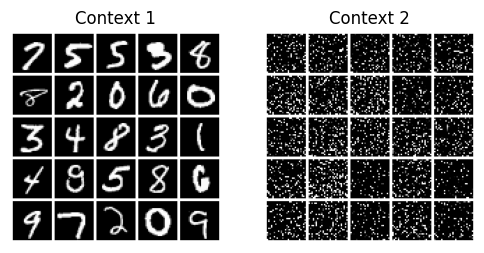

In [5]:
# MNIST Dataloaders
transform = transforms.ToTensor()
mnist_trainset = datasets.MNIST(root='./Mnist', train=True, download=True, transform= transforms.ToTensor())
mnist_testset = datasets.MNIST(root='./Mnist', train=False, download=True, transform= transforms.ToTensor())

len(mnist_trainset), len(mnist_testset) # 60000, 10000
config = {'size': 28, 'channels': 1, 'classes': 10}

#@title Visualization functions
def multi_context_barplot(axis, accs, title=None):
    '''Generate barplot using the values in [accs].'''
    contexts = len(accs)
    axis.bar(range(contexts), accs, color='k')
    axis.set_ylabel('Testing Accuracy (%)')
    axis.set_xticks(range(contexts), [f'Context {i+1}' for i in range(contexts)])
    if title is not None:
        axis.set_title(title)

def plot_examples(axis, dataset, context_id=None):
    '''Plot 25 examples from [dataset].'''
    data_loader = torch.utils.data.DataLoader(dataset, batch_size=25, shuffle=True)
    image_tensor, _ = next(iter(data_loader))
    image_grid = make_grid(image_tensor, nrow=5, pad_value=1) # pad_value=0 would give black borders
    axis.imshow(np.transpose(image_grid.numpy(), (1,2,0)))
    if context_id is not None:
        axis.set_title("Context {}".format(context_id+1))
    axis.axis('off')

# Function to apply a given permutation the pixels of an image.
def permutate_image_pixels(image, permutation):
    '''Permutate the pixels of [image] according to [permutation].'''

    if permutation is None:
        return image
    else:
        c, h, w = image.size()
        image = image.view(c, -1)
        image = image[:, permutation]  #--> same permutation for each channel
        image = image.view(c, h, w)
        return image
    
# Class to create a dataset with images that have all been transformed in the same way.
class TransformedDataset(torch.utils.data.Dataset):
    '''To modify an existing dataset with a transform.
    Useful for creating different permutations of MNIST without loading the data multiple times.'''

    def __init__(self, original_dataset, transform=None, target_transform=None):
        super().__init__()
        self.dataset = original_dataset
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        (input, target) = self.dataset[index]
        if self.transform:
            input = self.transform(input)
        if self.target_transform:
            target = self.target_transform(target)
        return (input, target)
    
import numpy as np
contexts = 2 
permutations = [None] + [np.random.permutation(config['size']**2) for _ in range(contexts-1)]
# Specify for each context the transformed train- and testset
train_datasets = []
test_datasets = []
for context_id, perm in enumerate(permutations):
    train_datasets.append(TransformedDataset(
        mnist_trainset, transform=transforms.Lambda(lambda x, p=perm: permutate_image_pixels(x, p)),
    ))
    test_datasets.append(TransformedDataset(
        mnist_testset, transform=transforms.Lambda(lambda x, p=perm: permutate_image_pixels(x, p)),
    ))

# Visualize the contexts
figure, axis = plt.subplots(1, contexts, figsize=(3*contexts, 4))

for context_id in range(len(train_datasets)):
    plot_examples(axis[context_id], train_datasets[context_id], context_id=context_id)


### Define the training and the evaluation function 

In [6]:
# Training function
def train(model, loader, optimizer, criterion, epochs=1):
    model.to(device)
    for epoch in range(epochs):
        model.train()
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

In [7]:
# Evaluation function
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
    return correct / total

### Now train the PNN network: first on the first context using the first column


In [8]:
# Train Task 1 (original MNIST)
model1 = PNN()
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
train_loader_1 = DataLoader(train_datasets[0], batch_size=64, shuffle=True)
test_loader_1 = DataLoader(test_datasets[0], batch_size=64, shuffle=False)
print("Training Task 1 (MNIST)")
train(model1, train_loader_1, optimizer1, criterion, epochs=10)
acc1 = evaluate(model1, test_loader_1)
print("Task 1 Test Accuracy:", acc1)

Training Task 1 (MNIST)


Epoch 1, Loss: 0.0269
Epoch 2, Loss: 0.0640
Epoch 3, Loss: 0.0154
Epoch 4, Loss: 0.1230
Epoch 5, Loss: 0.0005
Epoch 6, Loss: 0.0011
Epoch 7, Loss: 0.0615
Epoch 8, Loss: 0.0042
Epoch 9, Loss: 0.0000
Epoch 10, Loss: 0.0118
Task 1 Test Accuracy: 0.9911


### Then train on the second context using the second column 

In [9]:
# Save the frozen model for Task 1
frozen_model = copy.deepcopy(model1.task_model)
torch.save(frozen_model.state_dict(), './baseline1.pth')

In [10]:
# Train Task 2 (Permuted MNIST)
model2 = PNN(prev_model=frozen_model)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)
train_loader_2 = DataLoader(train_datasets[1], batch_size=64, shuffle=True)
test_loader2 = DataLoader(test_datasets[1], batch_size=64, shuffle=False)
print("\nTraining Task 2 (Permuted MNIST)")
train(model2, train_loader_2, optimizer2, criterion, epochs=5)
acc2 = evaluate(model2, test_loader2)
print("Task 2 Test Accuracy:", acc2)


Training Task 2 (Permuted MNIST)


Epoch 1, Loss: 0.2699
Epoch 2, Loss: 0.1150
Epoch 3, Loss: 0.0886
Epoch 4, Loss: 0.2587
Epoch 5, Loss: 0.2496
Task 2 Test Accuracy: 0.9591


In [11]:
# Visualize the results
print(f'The test accuracy on task 2: {evaluate(model2, test_loader2)*100:.2f}%')
print(f'The test accuracy on task 1: {evaluate(model2.prev_model, test_loader_1)*100:.2f}%')
# Plotting the accuracies



The test accuracy on task 2: 95.91%
The test accuracy on task 1: 99.11%


#### Now let's compare the PNN evaluation result with the basline training setups mentioned in the introduction of this tutorial. 
- Define all the baselines mentioned above
- Individually train on the second context 
- Report the accuracy on the first context

In [12]:
""" TO-DO  """

### Baseline 1 

class SimpleCNN(nn.Module):
    def __init__(self, input_channels=1, output_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.fc1 = nn.Linear(32 * 7 * 7, 100)
        self.fc2 = nn.Linear(100, output_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x) 

In [13]:
from typing import Sequence

#for names, params in model.named_parameters():
#    if not names.startswith('fc'):
#        params.requires_grad = False


def set_grad(model, requires_grad: bool):
    for param in model.parameters():
        param.requires_grad = requires_grad

def iterate_layers(model):
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            yield m

def count_layers(model: nn.Module):
    return sum(1 for _ in iterate_layers(model))

# Freeze the n first layers
def freeze_unfreeze_layers(model, layers:Sequence, freeze: bool):
    for i, m in enumerate(iterate_layers(model)):
        if i in layers:
            set_grad(m, not freeze)
    
# randomly initialize the last n layers
def random_init_layers(model, layers:Sequence):
    for i, m in enumerate(iterate_layers(model)):
        if i in layers:
            for mm in m.modules():
                if isinstance(mm, nn.Conv2d):
                    nn.init.kaiming_normal_(mm.weight, mode='fan_out', nonlinearity='relu')
                elif isinstance(mm, nn.BatchNorm2d):
                    nn.init.constant_(mm.weight, 1)
                    nn.init.constant_(mm.bias, 0)
                elif isinstance(mm, nn.Linear):
                    nn.init.xavier_normal_(mm.weight)
                    nn.init.constant_(mm.bias, 0)
                

# Train Task 2 with the frozen model
#optimizer2 = torch.optim.Adam(model.parameters(), lr=0.001)
#train(model, train_loader_2, optimizer2, criterion, epochs=3)
#acc_baseline2 = evaluate(model, test_loader2)
#print("Baseline 2 Test Accuracy:", acc_baseline2)

#### Train Baseline 1: Finetune the whole network

In [15]:
model = SimpleCNN()
model.load_state_dict(torch.load('./baseline1.pth'))
#random_init_layers(model, [0,1,2,3])
optimizer2 = torch.optim.Adam(model.parameters(), lr=0.001)
train(model, train_loader_2, optimizer2, criterion, epochs=5)
acc_baseline2 = evaluate(model, test_loader2)
print("Baseline 1 Test Accuracy on Task 2:", acc_baseline2)
acc_baseline1 = evaluate(model, test_loader_1)
print("Baseline 1 Test Accuracy on Task 1:", acc_baseline1)

Epoch 1, Loss: 0.1134
Epoch 2, Loss: 0.0263
Epoch 3, Loss: 0.0324
Epoch 4, Loss: 0.0976
Epoch 5, Loss: 0.0445
Baseline 1 Test Accuracy on Task 2: 0.9664
Baseline 1 Test Accuracy on Task 1: 0.5816


#### Train Baseline 2: Randomly initialize the last layer and finetune only the last layer while freezing the rest

In [16]:
model = SimpleCNN()
model.load_state_dict(torch.load('./baseline1.pth'))
count_layers(model)
freeze_unfreeze_layers(model, [0, 1, 2], freeze=True)
random_init_layers(model, [3])

In [17]:
optimizer2 = torch.optim.Adam(model.parameters(), lr=0.001)
train(model, train_loader_2, optimizer2, criterion, epochs=5)
acc_baseline2 = evaluate(model, test_loader2)
print("Baseline 2 Test Accuracy:", acc_baseline2)
acc_baseline1 = evaluate(model, test_loader_1)
print("Baseline 1 Test Accuracy on Task 1:", acc_baseline1)

Epoch 1, Loss: 1.8019
Epoch 2, Loss: 1.3271
Epoch 3, Loss: 1.0101
Epoch 4, Loss: 1.3797
Epoch 5, Loss: 0.8162
Baseline 2 Test Accuracy: 0.6407
Baseline 1 Test Accuracy on Task 1: 0.1709


#### Train Baseline 3: Randomly initialize the last layer and finetune the whole network


In [19]:
model = SimpleCNN()
model.load_state_dict(torch.load('./baseline1.pth'))
random_init_layers(model, [3])
optimizer2 = torch.optim.Adam(model.parameters(), lr=0.001)
train(model, train_loader_2, optimizer2, criterion, epochs=5)
acc_baseline2 = evaluate(model, test_loader2)
print("Baseline 3 Test Accuracy:", acc_baseline2)
acc_baseline1 = evaluate(model, test_loader_1)
print("Baseline 1 Test Accuracy on Task 1:", acc_baseline1)

Epoch 1, Loss: 0.0363
Epoch 2, Loss: 0.2264
Epoch 3, Loss: 0.3811
Epoch 4, Loss: 0.0478
Epoch 5, Loss: 0.0140
Baseline 3 Test Accuracy: 0.9664
Baseline 1 Test Accuracy on Task 1: 0.0831


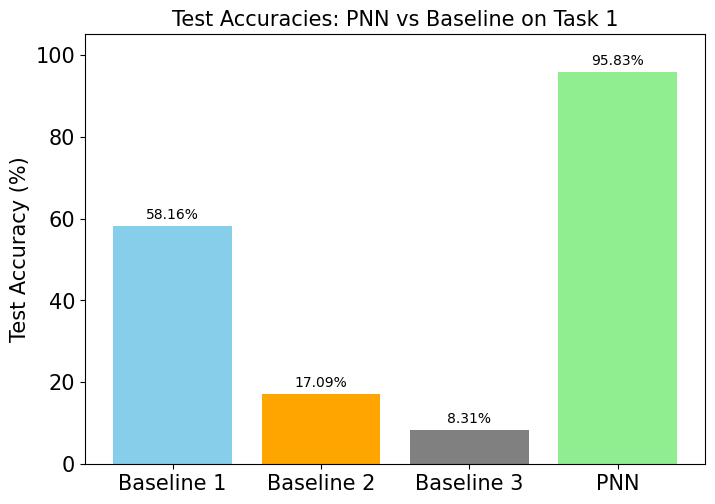

In [21]:
import matplotlib.pyplot as plt

# Example: replace with your actual accuracy values
baseline_1 = 58.16
baseline_2 = 17.09
baseline_3 = 8.31
PNN_accuracy = 95.83


labels = ['Baseline 1', 'Baseline 2', 'Baseline 3', 'PNN']
accuracies = [baseline_1, baseline_2, baseline_3, PNN_accuracy]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accuracies, color=['skyblue', 'orange', 'gray', 'lightgreen'])
plt.ylabel('Test Accuracy (%)', fontsize=15)
plt.title('Test Accuracies: PNN vs Baseline on Task 1', fontsize=15)
plt.ylim(0, 105)

# Annotate bars with values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', va='bottom', fontsize=10)

#plt.tight_layout()
plt.subplots_adjust(bottom=0.02)  # Add extra space at the bottom if needed
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.show()